# 1. Standardization: A Comprehensive Guide to Feature Standardization (Z-Score Normalization)

## 1. Definition & Mathematical Formulation

Standardization (also referred to as Z-Score Normalization) transforms continuous numeric features so that the resulting distribution has a mean ($\mu$) of exactly $0$ and a variance ($\sigma^2$) / standard deviation ($\sigma$) of exactly $1$.

**Note on Standard Deviation:** A common misconception is that standardization bounds the standard deviation between $-1$ and $+1$. Standard deviation is always a non-negative scalar ($\sigma \ge 0$), and after standardization, it is scaled to precisely $1$. The individual standardized values ($z$-scores) can be positive, negative, and theoretically unbounded ($-\infty$ to $+\infty$), though for normally distributed data, approximately $99.7\%$ of values fall between $[-3, 3]$.

### The Transformation Formula

For each feature value $x_i$:

$$z = \frac{x_i - \mu}{\sigma}$$

Where:
* $x_i$: The original feature value.
* $\mu$: The sample mean of the feature column:
  $$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$
* $\sigma$: The standard deviation of the feature column:
  $$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}$$

The transformation performs two fundamental geometric operations:

*   **Mean Centering ($x_i - \mu$):** Shifts the entire distribution along the coordinate axis so that the center of mass aligns with the origin ($0$).
*   **Scaling ($\div \sigma$):** Contracts or expands the spread of the data so that one unit of measurement along the axis represents exactly one standard deviation.

## 2. Primary Use Cases: Algorithms That Require Standardization

Standardization is essential for algorithms sensitive to coordinate geometry, scale magnitudes, or weight penalization.

### A. Distance-Based Algorithms

*   **K-Nearest Neighbors (KNN):** Computes pairwise geometric distances (such as Euclidean distance: $\sqrt{\sum (p_j - q_j)^2}$). Features with large raw scales (e.g., Annual Income in thousands) drown out smaller features (e.g., Age in decades). Standardization ensures each dimension contributes proportionally.
*   **K-Means Clustering:** Assigns cluster centroids via Euclidean distance minimizations; unscaled features distort cluster geometry into elongated hyper-ellipsoids.
*   **Support Vector Machines (SVM):** Margin maximization and kernel projections (like RBF kernels: $\exp(-\gamma \Vert{}x - x'\Vert{}^2)$) rely heavily on isotropic distance measurements.

### B. Gradient-Based Optimization

*   **Logistic & Linear Regression, Neural Networks:** Features on disparate scales cause the cost function contours to stretch into narrow, steep valleys (elliptical level curves). Gradient descent steps oscillate perpendicularly rather than heading directly toward the minimum, requiring smaller learning rates and significantly more training epochs. Standardization turns the contours roughly spherical, enabling direct, stable, and faster convergence.

### C. Regularized Linear Models

*   **Ridge ($L_2$) and Lasso ($L_1$) Regression:** Regularization adds an explicit penalty term to the loss function: $\lambda \sum \vert{}w_j\vert{}$ or $\lambda \sum w_j^2$. A feature with small raw magnitudes naturally requires a large model weight $w_j$ to exert predictive influence. The regularizer penalizes this large coefficient disproportionately, inadvertently shrinking informative signals.

### D. Variance-Maximizing Dimensionality Reduction

*   **Principal Component Analysis (PCA):** PCA finds orthogonal projection axes that maximize sample variance. If one variable has an arbitrary scale variance of $10,000$ and another has $0.5$, PCA assigns nearly all explained variance to the first column simply due to units, ignoring structural relationships.

## 3. Algorithms That Do NOT Require Standardization

*   **Tree-Based Models:** Decision Trees, Random Forests, Extra Trees, Gradient Boosting Machines (XGBoost, LightGBM, CatBoost).
    *   **Reason:** Tree nodes split using individual feature inequality thresholds ($x_j \le \theta$). Monotonic, order-preserving transformations do not alter split ordering, ranking, or impurity evaluations (Gini / Entropy).
*   **Naive Bayes:** Class conditional densities are computed per feature independently without geometric cross-feature interference.

## 4. Drawbacks, Pitfalls, and Failure Modes

### A. Vulnerability to Outliers

Because both the sample mean ($\mu$) and sample standard deviation ($\sigma$) are calculated using all observations, extreme outliers exert disproportionate leverage. A massive outlier inflates $\sigma$ and shifts $\mu$, pulling the standardized values of normal inliers into an artificially narrow cluster around zero.

*   **Alternative:** When extreme outliers cannot be trimmed, use `RobustScaler`, which centers via the median and scales via the Interquartile Range ($\text{IQR} = Q_3 - Q_1$).

### B. Destruction of Natural Sparsity

If a dataset contains many zeros (such as sparse term-document matrices or high-cardinality one-hot encoded features), subtracting $\mu$ replaces zero entries with $-\mu / \sigma$. This converts a memory-efficient sparse matrix into a dense array, which can easily trigger out-of-memory (OOM) errors.

*   **Alternative:** Use `MaxAbsScaler`, which divides strictly by the absolute maximum and preserves zero elements.

### C. Unbounded Output Range

Unlike Min-Max scaling, standardization does not guarantee that transformed values fall within a fixed, bounded interval like $[0, 1]$ or $[-1, 1]$. Algorithms that explicitly require bounded inputs (such as image inputs fed into bounded activation functions or specific perceptual models) can fail or saturate.

### D. Distribution Shape Remains Unchanged

Standardization does not convert a skewed distribution into a normal (Gaussian) distribution. It simply shifts the center and rescales the axis. If a feature is heavily right-skewed (log-normal, power law), it remains skewed after standardization. Power transforms (like Box-Cox or Yeo-Johnson) must be used if true normality is required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df = df.iloc[:,2:]

In [4]:
df.sample(12)

,Age,EstimatedSalary,Purchased
144,34,25000,0
386,49,39000,1
46,25,79000,0
337,35,79000,0
234,38,112000,0
371,60,83000,1
160,32,100000,1
190,24,84000,0
162,37,33000,0
42,35,108000,0


~> Train test split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)
X_test.shape , X_train.shape

((120, 2), (280, 2))

##StandardScaler

In [10]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()

Scaler.fit(X_train)
X_train_scaled = Scaler.transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [11]:
Scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [12]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [13]:
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [14]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [15]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [16]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## Effect of Scaling

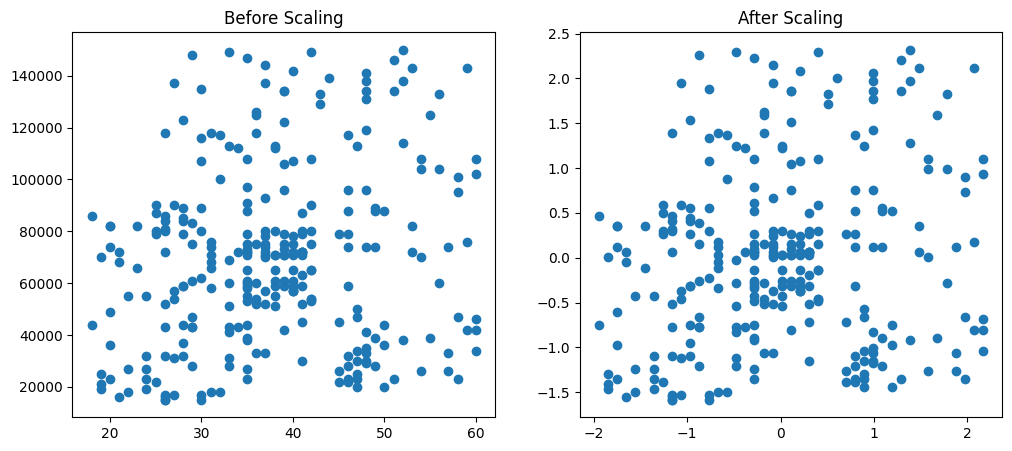

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'])
ax2.set_title('After Scaling')
plt.show()

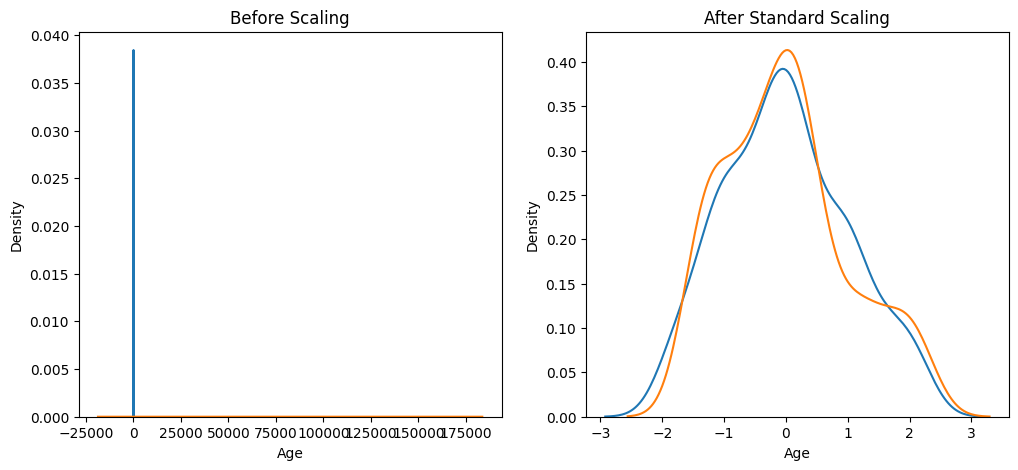

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

## Comparison of Distributions

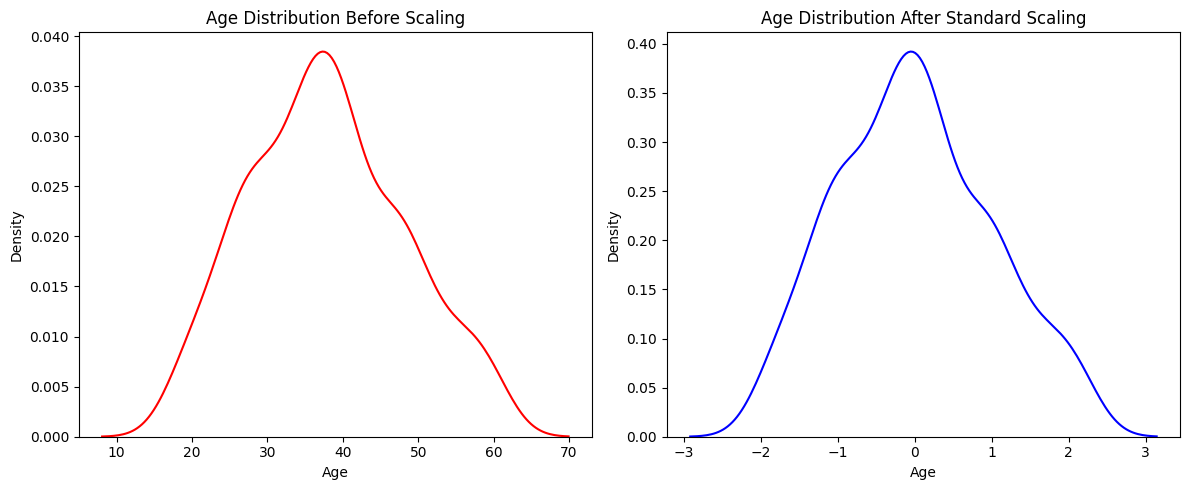

In [23]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# 1. Before Scaling Plot
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1, color='red')

# 2. After Standard Scaling Plot
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2, color='blue')

plt.tight_layout()
plt.show()

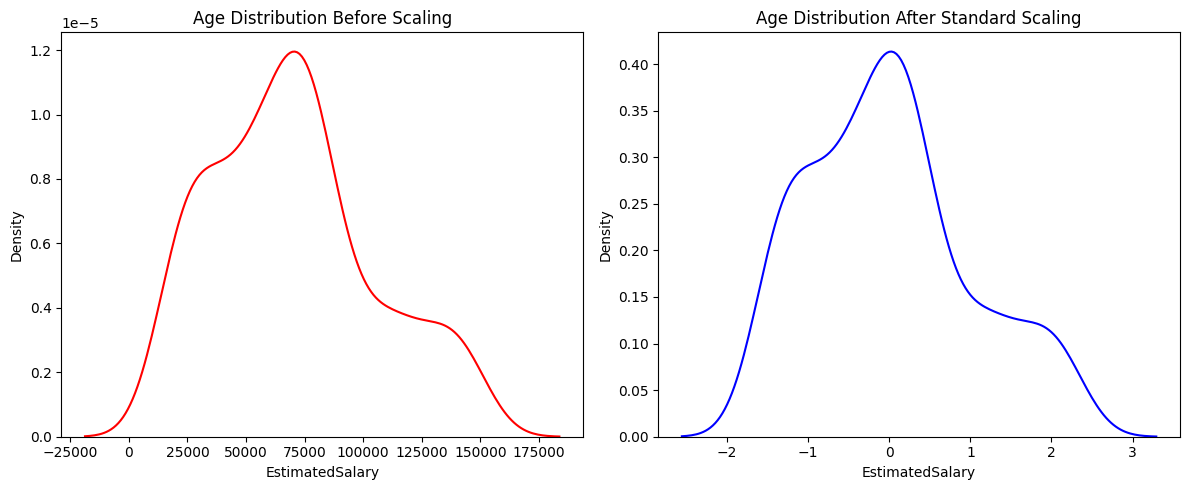

In [26]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# 1. Before Scaling Plot
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, color='red')

# 2. After Standard Scaling Plot
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, color='blue')

plt.tight_layout()
plt.show()

## Why Scaling is IMPORTANT !!!!

In [27]:
from sklearn.linear_model import LogisticRegression


In [30]:
lr = LogisticRegression()
lr.scaled = LogisticRegression()
lr.fit(X_train, y_train)
lr.scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [32]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr.scaled.predict(X_test_scaled)

In [34]:
from sklearn.metrics import accuracy_score

In [36]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [37]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [39]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [40]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.875


In [41]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


## Effect of OUTLIER

In [44]:
# নতুন ৩টি রো তৈরি করা (এগুলো মূলত extreme outlier টেস্ট করার জন্য যোগ করা হচ্ছে)
new_data = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

# মূল DataFrame-এর সাথে যুক্ত করা
df = pd.concat([df, new_data], ignore_index=True)
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
401,90,250000,1
402,95,350000,1
403,5,1000,0
404,90,250000,1


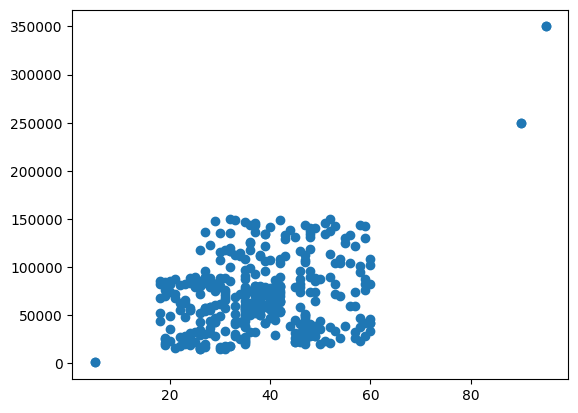

In [45]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((284, 2), (122, 2))

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

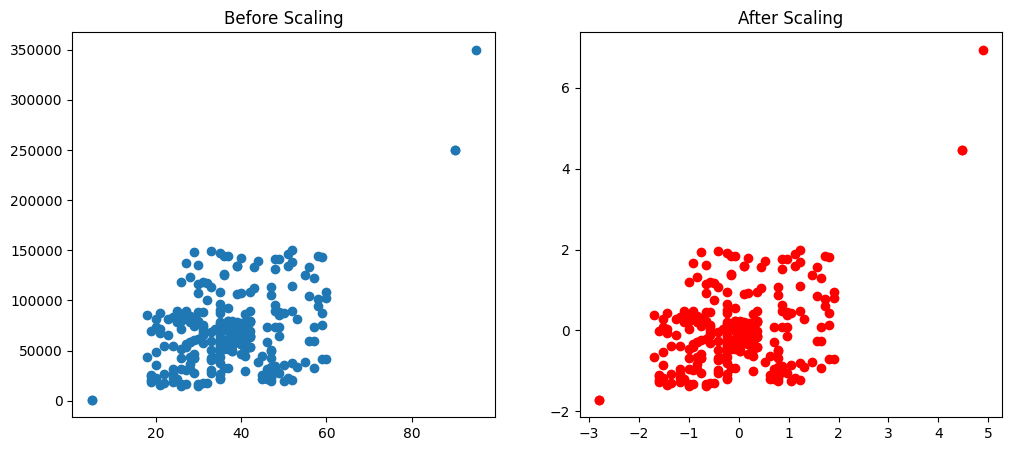

In [49]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

See there is no difference created by standardization , so we can say that in standardization we have to set the outliers by another method this is one of the drawew backs of standardixation